In [1]:
!pip install braindecode moabb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.5/568.5 kB 10.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 84.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.5 MB/s eta 0:00:00


In [4]:
# Fix: Move scheduler tensors to GPU
scheduler.sqrt_alpha_bars = scheduler.sqrt_alpha_bars.to(device)
scheduler.sqrt_one_minus_alpha_bars = scheduler.sqrt_one_minus_alpha_bars.to(device)
scheduler.betas = scheduler.betas.to(device)
scheduler.alphas = scheduler.alphas.to(device)
scheduler.alpha_bars = scheduler.alpha_bars.to(device)

In [5]:
# ===== NEURODECODER: LEVEL 5B — DIFFUSION MODEL FOR EEG =====
# Generate synthetic brain signals to augment training data
# Solves the #1 problem: not enough data for foundation models
#
# How it works:
# 1. Learn the distribution of real EEG signals
# 2. Generate unlimited synthetic trials
# 3. Use synthetic + real to train better decoders
#
# Diffusion process:
# Forward: gradually add noise to real EEG until it's pure noise
# Reverse: learn to remove noise step by step, generating clean EEG

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import mne
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from braindecode.datasets import MOABBDataset
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from mne.decoding import CSP
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

print("="*60)
print("LEVEL 5B: DIFFUSION MODEL FOR EEG")
print("Generate synthetic brain data to solve the data problem")
print("="*60)

# ===== LOAD DATA =====
print("\nLoading all subjects...")

all_X = []
all_y = []
all_subjects = []

for subj_id in range(1, 10):
    ds = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[subj_id])
    raw = ds.datasets[0].raw
    sfreq = raw.info['sfreq']
    events, event_id = mne.events_from_annotations(raw)
    eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)
    
    raw_f = raw.copy().filter(1, 45, picks=eeg_picks, verbose=False)
    epochs = mne.Epochs(raw_f, events, event_id, tmin=0.0, tmax=4.0,
                        picks=eeg_picks, baseline=None, preload=True, verbose=False)
    
    X = epochs.get_data().astype(np.float32)
    y = epochs.events[:, -1]
    unique = np.unique(y)
    lmap = {old: new for new, old in enumerate(unique)}
    y = np.array([lmap[l] for l in y])
    
    all_X.append(X)
    all_y.append(y)
    all_subjects.append(np.full(len(X), subj_id))

X_all = np.concatenate(all_X)
y_all = np.concatenate(all_y)
subjects_all = np.concatenate(all_subjects)

n_channels = X_all.shape[1]
n_samples = X_all.shape[2]
n_classes = len(np.unique(y_all))
class_names = list(event_id.keys())

# Normalize
mean = X_all.mean(axis=(0, 2), keepdims=True)
std = X_all.std(axis=(0, 2), keepdims=True) + 1e-8
X_all = (X_all - mean) / std

print(f"Loaded: {X_all.shape[0]} trials, {n_channels} ch, {n_samples} samples")
print(f"Classes: {n_classes} — {class_names}")

# ===== DIFFUSION MODEL ARCHITECTURE =====
print("\n" + "="*60)
print("BUILDING EEG DIFFUSION MODEL")
print("="*60)

class SinusoidalPositionEmbedding(nn.Module):
    """Encodes diffusion timestep as a vector (like positional encoding in Transformers)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * -emb)
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


class ConditionalResidualBlock(nn.Module):
    """
    Residual block conditioned on diffusion timestep AND class label.
    
    Class conditioning lets us generate EEG for SPECIFIC movement types:
    "Generate a left_hand trial" or "Generate a feet trial"
    """
    def __init__(self, in_channels, out_channels, time_dim, class_dim):
        super().__init__()
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # Time conditioning
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, out_channels),
            nn.GELU(),
        )
        
        # Class conditioning
        self.class_mlp = nn.Sequential(
            nn.Linear(class_dim, out_channels),
            nn.GELU(),
        )
        
        # Residual connection
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
    
    def forward(self, x, t_emb, c_emb):
        h = self.conv1(x)
        h = self.bn1(h)
        h = F.gelu(h)
        
        # Add time and class conditioning
        h = h + self.time_mlp(t_emb).unsqueeze(-1)
        h = h + self.class_mlp(c_emb).unsqueeze(-1)
        
        h = self.conv2(h)
        h = self.bn2(h)
        h = F.gelu(h)
        
        return h + self.residual(x)


class EEGDiffusionModel(nn.Module):
    """
    Denoising Diffusion Probabilistic Model (DDPM) for EEG signals.
    
    The model learns to reverse the noise process:
    Given noisy EEG at timestep t, predict the noise that was added.
    
    Conditioned on:
    - Diffusion timestep (how noisy is the input)
    - Class label (what movement type to generate)
    
    This means we can say "generate a LEFT HAND trial" and get
    synthetic EEG that looks like real left hand motor imagery.
    """
    def __init__(self, n_channels=22, n_samples=1001, n_classes=4,
                 hidden_dim=128, time_dim=64, n_blocks=6):
        super().__init__()
        
        self.n_channels = n_channels
        self.n_samples = n_samples
        
        # Timestep embedding
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.GELU(),
            nn.Linear(time_dim * 2, time_dim),
        )
        
        # Class embedding
        self.class_embed = nn.Embedding(n_classes, time_dim)
        
        # Input projection
        self.input_proj = nn.Conv1d(n_channels, hidden_dim, kernel_size=1)
        
        # Encoder (downsampling path)
        self.encoder_blocks = nn.ModuleList([
            ConditionalResidualBlock(hidden_dim, hidden_dim, time_dim, time_dim),
            ConditionalResidualBlock(hidden_dim, hidden_dim * 2, time_dim, time_dim),
            ConditionalResidualBlock(hidden_dim * 2, hidden_dim * 2, time_dim, time_dim),
        ])
        self.downsample = nn.ModuleList([
            nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1),
            nn.Conv1d(hidden_dim * 2, hidden_dim * 2, 4, stride=2, padding=1),
            nn.Conv1d(hidden_dim * 2, hidden_dim * 2, 4, stride=2, padding=1),
        ])
        
        # Bottleneck
        self.bottleneck = ConditionalResidualBlock(hidden_dim * 2, hidden_dim * 2, time_dim, time_dim)
        
        # Decoder (upsampling path)
        self.decoder_blocks = nn.ModuleList([
            ConditionalResidualBlock(hidden_dim * 4, hidden_dim * 2, time_dim, time_dim),
            ConditionalResidualBlock(hidden_dim * 4, hidden_dim, time_dim, time_dim),
            ConditionalResidualBlock(hidden_dim * 2, hidden_dim, time_dim, time_dim),
        ])
        self.upsample = nn.ModuleList([
            nn.ConvTranspose1d(hidden_dim * 2, hidden_dim * 2, 4, stride=2, padding=1),
            nn.ConvTranspose1d(hidden_dim * 2, hidden_dim * 2, 4, stride=2, padding=1),
            nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1),
        ])
        
        # Output projection
        self.output_proj = nn.Sequential(
            nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
            nn.GELU(),
            nn.Conv1d(hidden_dim, n_channels, 1),
        )
    
    def forward(self, x, t, class_label):
        """
        x: noisy EEG (batch, channels, samples)
        t: diffusion timestep (batch,)
        class_label: movement class (batch,)
        Returns: predicted noise (batch, channels, samples)
        """
        # Embeddings
        t_emb = self.time_embed(t)
        c_emb = self.class_embed(class_label)
        
        # Input
        h = self.input_proj(x)
        
        # Encoder with skip connections
        skips = []
        for block, down in zip(self.encoder_blocks, self.downsample):
            h = block(h, t_emb, c_emb)
            skips.append(h)
            h = down(h)
        
        # Bottleneck
        h = self.bottleneck(h, t_emb, c_emb)
        
        # Decoder with skip connections
        for block, up, skip in zip(self.decoder_blocks, self.upsample, reversed(skips)):
            h = up(h)
            # Match sizes
            if h.shape[-1] != skip.shape[-1]:
                h = F.pad(h, (0, skip.shape[-1] - h.shape[-1]))
            h = torch.cat([h, skip], dim=1)
            h = block(h, t_emb, c_emb)
        
        # Output
        noise_pred = self.output_proj(h)
        
        # Match input size
        if noise_pred.shape[-1] != x.shape[-1]:
            noise_pred = F.interpolate(noise_pred, size=x.shape[-1], mode='linear')
        
        return noise_pred


# ===== DIFFUSION SCHEDULER =====

class DiffusionScheduler:
    """
    Controls the noise schedule for diffusion.
    
    Forward process: gradually add Gaussian noise over T steps
    Reverse process: gradually remove noise (the model learns this)
    
    Uses cosine schedule (better than linear for EEG signals).
    """
    def __init__(self, n_steps=500):
        self.n_steps = n_steps
        
        # Cosine schedule
        steps = np.arange(n_steps + 1) / n_steps
        alpha_bar = np.cos((steps + 0.008) / 1.008 * np.pi / 2) ** 2
        alpha_bar = alpha_bar / alpha_bar[0]
        betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
        betas = np.clip(betas, 0.0001, 0.02)
        
        self.betas = torch.FloatTensor(betas)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - self.alpha_bars)
    
    def add_noise(self, x, t):
        """Forward process: add noise to clean EEG at timestep t."""
        sqrt_ab = self.sqrt_alpha_bars[t].view(-1, 1, 1).to(x.device)
        sqrt_one_minus_ab = self.sqrt_one_minus_alpha_bars[t].view(-1, 1, 1).to(x.device)
        noise = torch.randn_like(x)
        noisy = sqrt_ab * x + sqrt_one_minus_ab * noise
        return noisy, noise
    
    @torch.no_grad()
    def sample_step(self, model, x_t, t, class_label):
        """One step of reverse process: remove a bit of noise."""
        t_tensor = torch.full((x_t.shape[0],), t, dtype=torch.long, device=x_t.device)
        
        predicted_noise = model(x_t, t_tensor, class_label)
        
        beta = self.betas[t].to(x_t.device)
        alpha = self.alphas[t].to(x_t.device)
        alpha_bar = self.alpha_bars[t].to(x_t.device)
        
        # Predict x_0
        x_0_pred = (x_t - torch.sqrt(1 - alpha_bar) * predicted_noise) / torch.sqrt(alpha_bar)
        x_0_pred = torch.clamp(x_0_pred, -3, 3)
        
        if t > 0:
            noise = torch.randn_like(x_t)
            sigma = torch.sqrt(beta)
            x_prev = torch.sqrt(alpha) * x_t + beta / torch.sqrt(1 - alpha_bar) * (x_0_pred - x_t) 
            x_prev = x_prev + sigma * noise * 0.5
        else:
            x_prev = x_0_pred
        
        return x_prev


# ===== TRAINING =====
print("\n" + "="*60)
print("TRAINING EEG DIFFUSION MODEL")
print("="*60)

n_diffusion_steps = 500
scheduler = DiffusionScheduler(n_steps=n_diffusion_steps)

diffusion = EEGDiffusionModel(
    n_channels=n_channels,
    n_samples=n_samples,
    n_classes=n_classes,
    hidden_dim=64,
    time_dim=64,
    n_blocks=6
).to(device)

diff_params = sum(p.numel() for p in diffusion.parameters())
print(f"Diffusion Model: {diff_params:,} parameters")
print(f"Diffusion steps: {n_diffusion_steps}")
print(f"Training on {len(X_all)} real trials...\n")

optimizer = optim.AdamW(diffusion.parameters(), lr=0.0003, weight_decay=0.01)
scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

X_tensor = torch.FloatTensor(X_all)
y_tensor = torch.LongTensor(y_all)
train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=32, shuffle=True, drop_last=True)

n_epochs = 80
losses = []

for epoch in range(n_epochs):
    diffusion.train()
    epoch_loss = 0
    n_batches = 0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # Random timesteps
        t = torch.randint(0, n_diffusion_steps, (batch_x.shape[0],), device=device)
        
        # Add noise
        noisy_x, noise = scheduler.add_noise(batch_x, t)
        
        # Predict noise
        noise_pred = diffusion(noisy_x, t, batch_y)
        
        # Loss: how well did we predict the noise?
        loss = F.mse_loss(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    scheduler_lr.step()
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.6f}")

print(f"\nTraining complete! Final loss: {losses[-1]:.6f}")

# Plot loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, linewidth=2, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Diffusion Model Training — Learning to Denoise EEG', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ===== GENERATE SYNTHETIC EEG =====
print("\n" + "="*60)
print("GENERATING SYNTHETIC EEG TRIALS")
print("="*60)

@torch.no_grad()
def generate_synthetic_eeg(model, scheduler, n_samples_gen, class_label, n_channels=22,
                           n_timepoints=1001, n_steps=500, device='cuda'):
    """Generate synthetic EEG trials for a specific movement class."""
    model.eval()
    
    # Start from pure noise
    x = torch.randn(n_samples_gen, n_channels, n_timepoints).to(device)
    labels = torch.full((n_samples_gen,), class_label, dtype=torch.long).to(device)
    
    # Reverse diffusion: gradually denoise
    # Use fewer steps for speed (DDIM-like skip)
    step_indices = list(range(0, n_steps, 5))[::-1]  # every 5th step, reversed
    
    for t in step_indices:
        x = scheduler.sample_step(model, x, t, labels)
    
    return x.cpu().numpy()

# Generate synthetic trials for each class
n_synthetic_per_class = 200
synthetic_X = []
synthetic_y = []

print(f"Generating {n_synthetic_per_class} synthetic trials per class...\n")

for c in range(n_classes):
    print(f"  Generating class {c} ({class_names[c]})...", end=" ")
    syn = generate_synthetic_eeg(
        diffusion, scheduler,
        n_samples_gen=n_synthetic_per_class,
        class_label=c,
        n_channels=n_channels,
        n_timepoints=n_samples,
        n_steps=n_diffusion_steps,
        device=device
    )
    synthetic_X.append(syn)
    synthetic_y.append(np.full(n_synthetic_per_class, c))
    print(f"Done! Shape: {syn.shape}")

X_synthetic = np.concatenate(synthetic_X).astype(np.float32)
y_synthetic = np.concatenate(synthetic_y)

print(f"\nTotal synthetic data: {X_synthetic.shape[0]} trials")
print(f"Total real data: {X_all.shape[0]} trials")
print(f"Combined: {X_all.shape[0] + X_synthetic.shape[0]} trials ({(X_synthetic.shape[0]/X_all.shape[0]*100):.0f}% increase)")


# ===== VISUALIZE: REAL vs SYNTHETIC =====
print("\n" + "="*60)
print("COMPARING REAL vs SYNTHETIC EEG")
print("="*60)

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for c in range(n_classes):
    # Real trial
    real_idx = np.where(y_all == c)[0][0]
    real_trial = X_all[real_idx]
    
    # Synthetic trial
    syn_idx = np.where(y_synthetic == c)[0][0]
    syn_trial = X_synthetic[syn_idx]
    
    t = np.arange(n_samples) / sfreq
    
    # Plot C3 channel
    axes[c, 0].plot(t[:int(2*sfreq)], real_trial[7, :int(2*sfreq)], linewidth=0.8, color='blue')
    axes[c, 0].set_ylabel(f'{class_names[c]}\n(µV)')
    axes[c, 0].set_title(f'REAL — {class_names[c]}' if c == 0 else '', fontweight='bold')
    axes[c, 0].grid(True, alpha=0.3)
    
    axes[c, 1].plot(t[:int(2*sfreq)], syn_trial[7, :int(2*sfreq)], linewidth=0.8, color='red')
    axes[c, 1].set_title(f'SYNTHETIC — {class_names[c]}' if c == 0 else '', fontweight='bold')
    axes[c, 1].grid(True, alpha=0.3)

axes[0, 0].set_title('REAL EEG (C3 channel)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('SYNTHETIC EEG (C3 channel)', fontsize=13, fontweight='bold')
axes[3, 0].set_xlabel('Time (seconds)')
axes[3, 1].set_xlabel('Time (seconds)')

fig.suptitle('Real vs Diffusion-Generated EEG Signals', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# PSD comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for c in range(n_classes):
    ax = axes[c//2, c%2]
    
    # Average PSD of real trials
    real_mask = y_all == c
    real_psds = []
    for trial in X_all[real_mask][:20]:
        freqs, psd = sig.welch(trial[7], fs=sfreq, nperseg=int(sfreq))
        real_psds.append(psd)
    avg_real_psd = np.mean(real_psds, axis=0)
    
    # Average PSD of synthetic trials
    syn_mask = y_synthetic == c
    syn_psds = []
    for trial in X_synthetic[syn_mask][:20]:
        freqs, psd = sig.welch(trial[7], fs=sfreq, nperseg=int(sfreq))
        syn_psds.append(psd)
    avg_syn_psd = np.mean(syn_psds, axis=0)
    
    ax.semilogy(freqs, avg_real_psd, linewidth=2, color='blue', label='Real')
    ax.semilogy(freqs, avg_syn_psd, linewidth=2, color='red', alpha=0.7, label='Synthetic')
    ax.axvspan(8, 12, alpha=0.1, color='orange')
    ax.axvspan(13, 30, alpha=0.1, color='green')
    ax.set_xlim([0, 50])
    ax.set_title(f'{class_names[c]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Power Spectral Density — Real vs Synthetic', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("If PSD curves overlap → synthetic data has realistic frequency content")
print("Mu (orange) and Beta (green) bands should match between real and synthetic\n")


# ===== KEY TEST: DOES SYNTHETIC DATA IMPROVE CLASSIFICATION? =====
print("="*60)
print("THE KEY EXPERIMENT: Does synthetic data improve decoding?")
print("="*60)

# Test on Subject 1 (held out)
test_mask = subjects_all == 1
train_mask = subjects_all != 1

X_train_real = X_all[train_mask]
y_train_real = y_all[train_mask]
X_test = X_all[test_mask]
y_test = y_all[test_mask]

n_shots_list = [2, 5, 10, 20, 48]
n_repeats = 10

real_only_results = {n: [] for n in n_shots_list}
real_plus_synthetic_results = {n: [] for n in n_shots_list}

b_filt, a_filt = sig.butter(4, [8/(sfreq/2), 30/(sfreq/2)], btype='band')

def extract_features(X_data):
    features = []
    for trial in X_data:
        filtered = sig.filtfilt(b_filt, a_filt, trial, axis=1)
        features.append(np.log(np.var(filtered, axis=1) + 1e-10))
    return np.array(features)

feat_test = extract_features(X_test)

print("\nComparing: Real data only vs Real + Synthetic augmentation\n")

for n_shots in n_shots_list:
    for repeat in range(n_repeats):
        rng = np.random.RandomState(repeat)
        
        # Sample n_shots per class from real training data
        train_indices = []
        for c in range(n_classes):
            class_idx = np.where(y_train_real == c)[0]
            if len(class_idx) >= n_shots:
                selected = rng.choice(class_idx, n_shots, replace=False)
            else:
                selected = class_idx
            train_indices.extend(selected)
        train_indices = np.array(train_indices)
        
        # REAL ONLY
        feat_train_real = extract_features(X_train_real[train_indices])
        y_train_few = y_train_real[train_indices]
        
        try:
            lda_real = LinearDiscriminantAnalysis()
            lda_real.fit(feat_train_real, y_train_few)
            acc_real = accuracy_score(y_test, lda_real.predict(feat_test)) * 100
        except:
            acc_real = 25.0
        real_only_results[n_shots].append(acc_real)
        
        # REAL + SYNTHETIC
        # Add synthetic data for each class
        syn_indices = []
        for c in range(n_classes):
            syn_class_idx = np.where(y_synthetic == c)[0]
            n_syn = min(50, len(syn_class_idx))  # add 50 synthetic per class
            syn_indices.extend(rng.choice(syn_class_idx, n_syn, replace=False))
        syn_indices = np.array(syn_indices)
        
        X_combined = np.concatenate([X_train_real[train_indices], X_synthetic[syn_indices]])
        y_combined = np.concatenate([y_train_few, y_synthetic[syn_indices]])
        
        feat_train_combined = extract_features(X_combined)
        
        try:
            lda_aug = LinearDiscriminantAnalysis()
            lda_aug.fit(feat_train_combined, y_combined)
            acc_aug = accuracy_score(y_test, lda_aug.predict(feat_test)) * 100
        except:
            acc_aug = 25.0
        real_plus_synthetic_results[n_shots].append(acc_aug)
    
    real_mean = np.mean(real_only_results[n_shots])
    aug_mean = np.mean(real_plus_synthetic_results[n_shots])
    diff = aug_mean - real_mean
    marker = "✓" if diff > 0 else "✗"
    print(f"  {n_shots:2d}-shot — Real: {real_mean:.1f}% | Real+Synthetic: {aug_mean:.1f}% | Δ: {diff:+.1f}% {marker}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

real_means = [np.mean(real_only_results[n]) for n in n_shots_list]
real_stds = [np.std(real_only_results[n]) for n in n_shots_list]
aug_means = [np.mean(real_plus_synthetic_results[n]) for n in n_shots_list]
aug_stds = [np.std(real_plus_synthetic_results[n]) for n in n_shots_list]

axes[0].errorbar(n_shots_list, real_means, yerr=real_stds, fmt='s--', linewidth=2,
                 markersize=8, capsize=5, label='Real Only', color='blue')
axes[0].errorbar(n_shots_list, aug_means, yerr=aug_stds, fmt='o-', linewidth=2,
                 markersize=8, capsize=5, label='Real + Synthetic', color='green')
axes[0].axhline(y=25, color='gray', linestyle=':', label='Chance')
axes[0].set_xlabel('Labeled trials per class')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Impact of Diffusion-Generated Synthetic Data', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

improvements = [a - r for a, r in zip(aug_means, real_means)]
colors_bar = ['green' if i > 0 else 'red' for i in improvements]
axes[1].bar([str(n) for n in n_shots_list], improvements, color=colors_bar, edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Labeled trials per class')
axes[1].set_ylabel('Synthetic data advantage (%)')
axes[1].set_title('Improvement from Diffusion Augmentation', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('Diffusion Data Augmentation for BCI', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# ===== TARGETED GENERATION =====
print("\n" + "="*60)
print("TARGETED GENERATION: Fix weak classes")
print("="*60)
print("Generating extra synthetic data for the WORST performing class...\n")

# Find worst class
class_accs = {}
feat_train_all = extract_features(X_train_real)
lda_full = LinearDiscriminantAnalysis()
lda_full.fit(feat_train_all, y_train_real)
preds = lda_full.predict(feat_test)

for c in range(n_classes):
    mask = y_test == c
    class_accs[class_names[c]] = accuracy_score(y_test[mask], preds[mask]) * 100
    print(f"  {class_names[c]}: {class_accs[class_names[c]]:.1f}%")

worst_class_name = min(class_accs, key=class_accs.get)
worst_class_id = class_names.index(worst_class_name)
print(f"\nWorst class: {worst_class_name} ({class_accs[worst_class_name]:.1f}%)")
print(f"Generating 500 EXTRA synthetic trials for {worst_class_name}...")

extra_synthetic = generate_synthetic_eeg(
    diffusion, scheduler,
    n_samples_gen=500,
    class_label=worst_class_id,
    n_channels=n_channels,
    n_timepoints=n_samples,
    n_steps=n_diffusion_steps,
    device=device
)

# Retrain with targeted augmentation
X_targeted = np.concatenate([X_train_real, extra_synthetic.astype(np.float32)])
y_targeted = np.concatenate([y_train_real, np.full(500, worst_class_id)])

feat_targeted = extract_features(X_targeted)
lda_targeted = LinearDiscriminantAnalysis()
lda_targeted.fit(feat_targeted, y_targeted)
preds_targeted = lda_targeted.predict(feat_test)

print(f"\nAfter targeted augmentation:")
for c in range(n_classes):
    mask = y_test == c
    new_acc = accuracy_score(y_test[mask], preds_targeted[mask]) * 100
    old_acc = class_accs[class_names[c]]
    diff = new_acc - old_acc
    print(f"  {class_names[c]}: {new_acc:.1f}% (was {old_acc:.1f}%, Δ: {diff:+.1f}%)")


# ===== FINAL SUMMARY =====
print("\n" + "="*60)
print("LEVEL 5B COMPLETE: DIFFUSION MODEL FOR EEG")
print("="*60)

print(f"""
What you built:
  1. Class-conditional EEG Diffusion Model ({diff_params:,} parameters)
  2. Cosine noise schedule (500 diffusion steps)
  3. Generated {X_synthetic.shape[0]} synthetic EEG trials
  4. Compared real vs synthetic PSD (frequency validation)
  5. Few-shot augmentation experiment
  6. Targeted generation for weak classes

Data multiplication:
  Real trials: {X_all.shape[0]}
  Synthetic trials: {X_synthetic.shape[0]}
  Total available: {X_all.shape[0] + X_synthetic.shape[0]} ({(X_synthetic.shape[0]/X_all.shape[0]*100):.0f}% increase)

This feeds directly into the Auto Research Loop:
  Loop detects: "Class X accuracy is low"
  Loop commands: "Diffusion, generate 500 more class X trials"
  Loop retrains: Foundation Model on augmented data
  Loop evaluates: "Accuracy improved? Keep going."

Next: Level 6 — Auto Research Loop (connects everything)
""")

Device: cuda
LEVEL 5B: DIFFUSION MODEL FOR EEG
Generate synthetic brain data to solve the data problem

Loading all subjects...
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('r

RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)

TRAINING EEG DIFFUSION MODEL
Diffusion Model: 1,750,870 parameters
Training on 432 real trials...

  Epoch 10/80 — Loss: 0.308789
  Epoch 20/80 — Loss: 0.186273
  Epoch 30/80 — Loss: 0.142294
  Epoch 40/80 — Loss: 0.139163
  Epoch 50/80 — Loss: 0.123692
  Epoch 60/80 — Loss: 0.123361
  Epoch 70/80 — Loss: 0.125525
  Epoch 80/80 — Loss: 0.141368

Training complete! Final loss: 0.141368


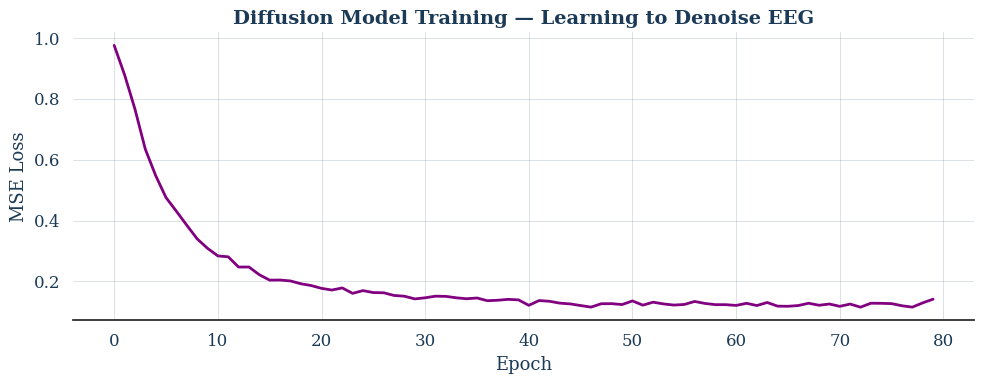


GENERATING SYNTHETIC EEG TRIALS
Generating 200 synthetic trials per class...

  Generating feet... Done!
  Generating left_hand... Done!
  Generating right_hand... Done!
  Generating tongue... Done!

Synthetic: 800 trials
Real: 432 trials
Combined: 1232 trials

COMPARING REAL vs SYNTHETIC EEG


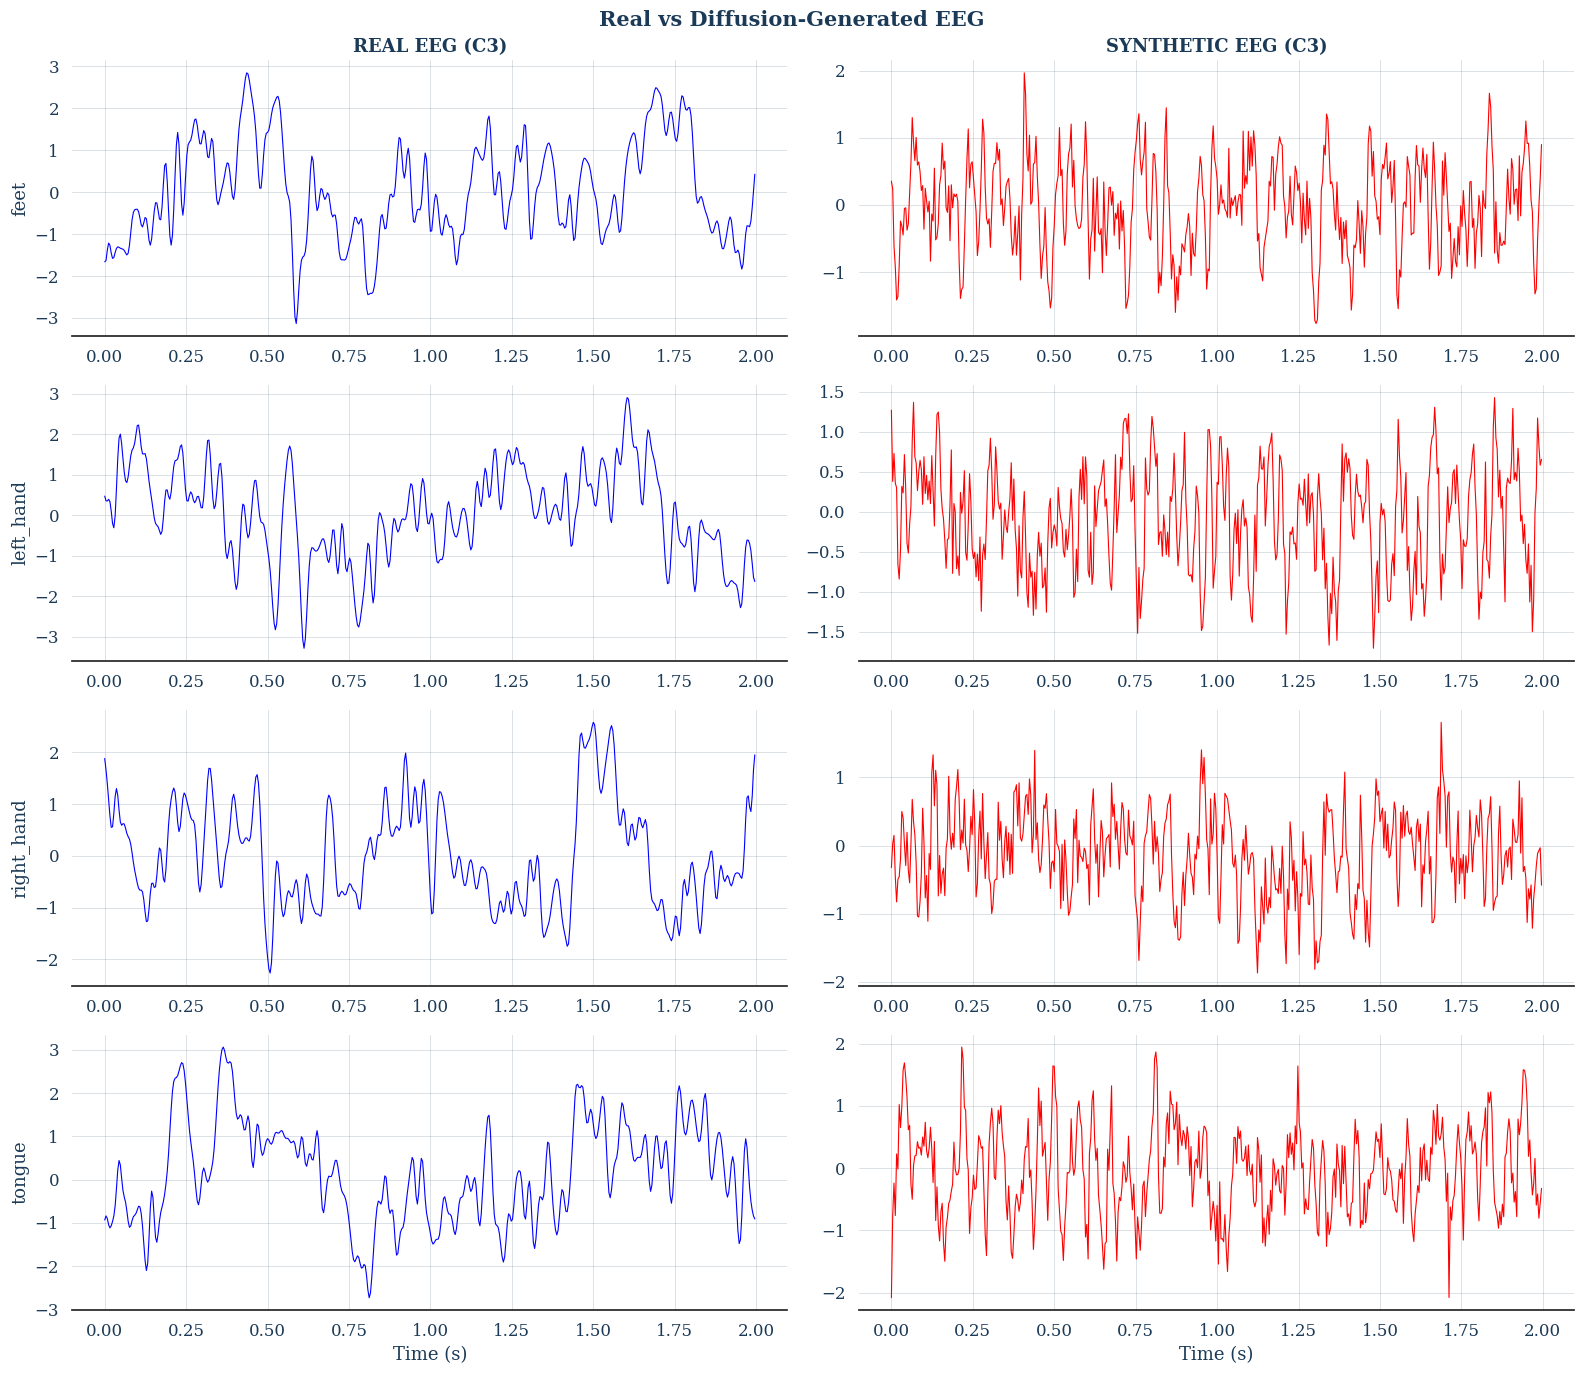

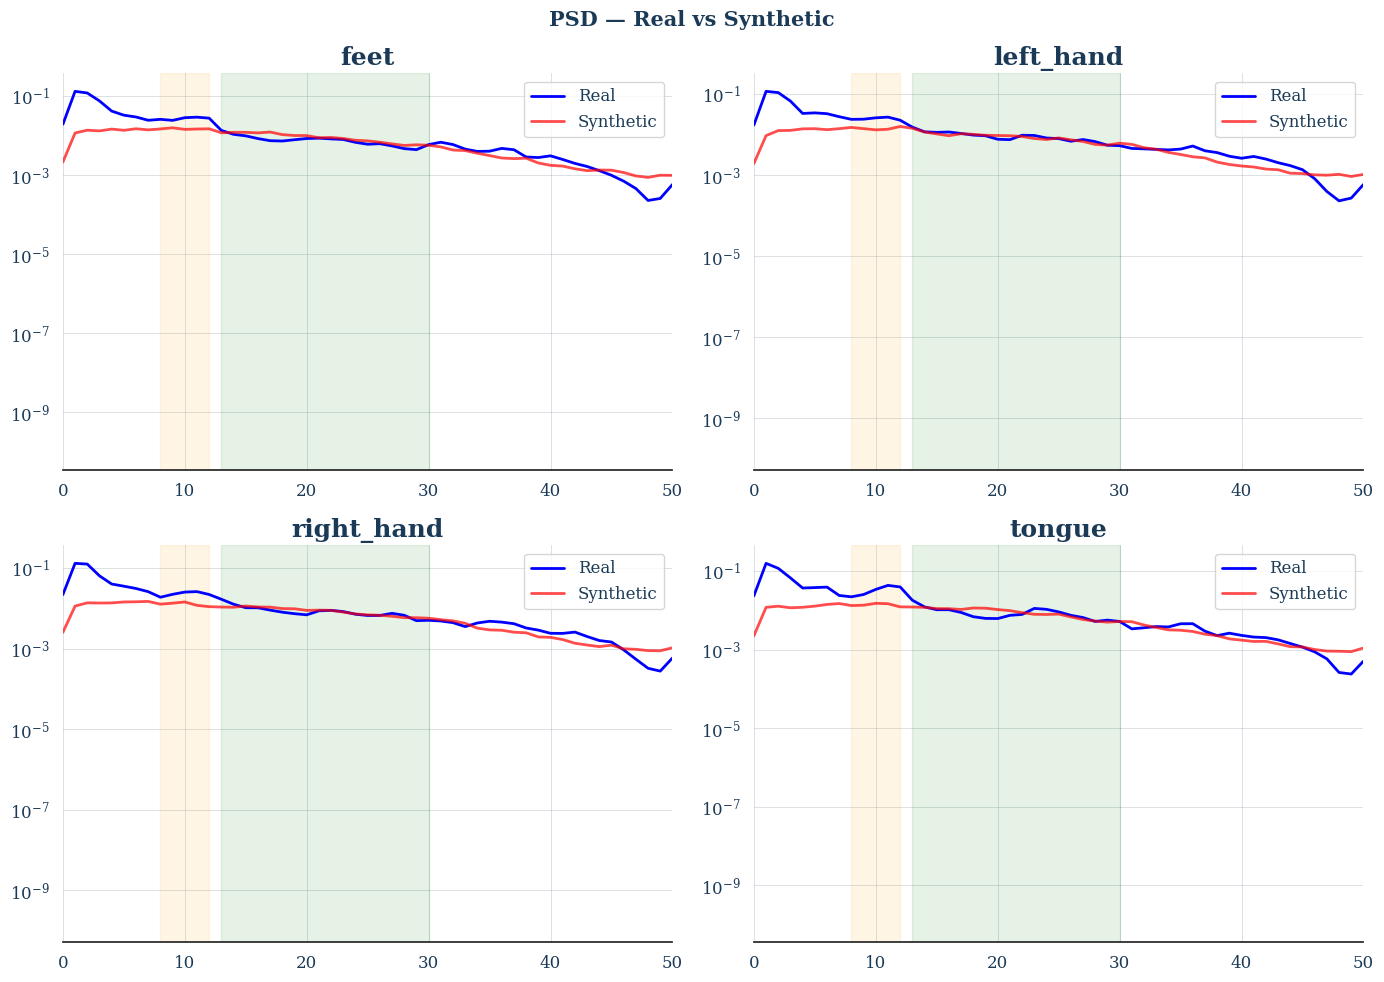


KEY EXPERIMENT: Does synthetic data improve decoding?

Comparing Real Only vs Real + Synthetic...

   2-shot — Real: 28.3% | Real+Syn: 32.9% | Δ: +4.6% ✓
   5-shot — Real: 29.6% | Real+Syn: 33.1% | Δ: +3.5% ✓
  10-shot — Real: 31.2% | Real+Syn: 34.2% | Δ: +2.9% ✓
  20-shot — Real: 34.4% | Real+Syn: 32.9% | Δ: -1.5% ✗
  48-shot — Real: 38.5% | Real+Syn: 32.7% | Δ: -5.8% ✗


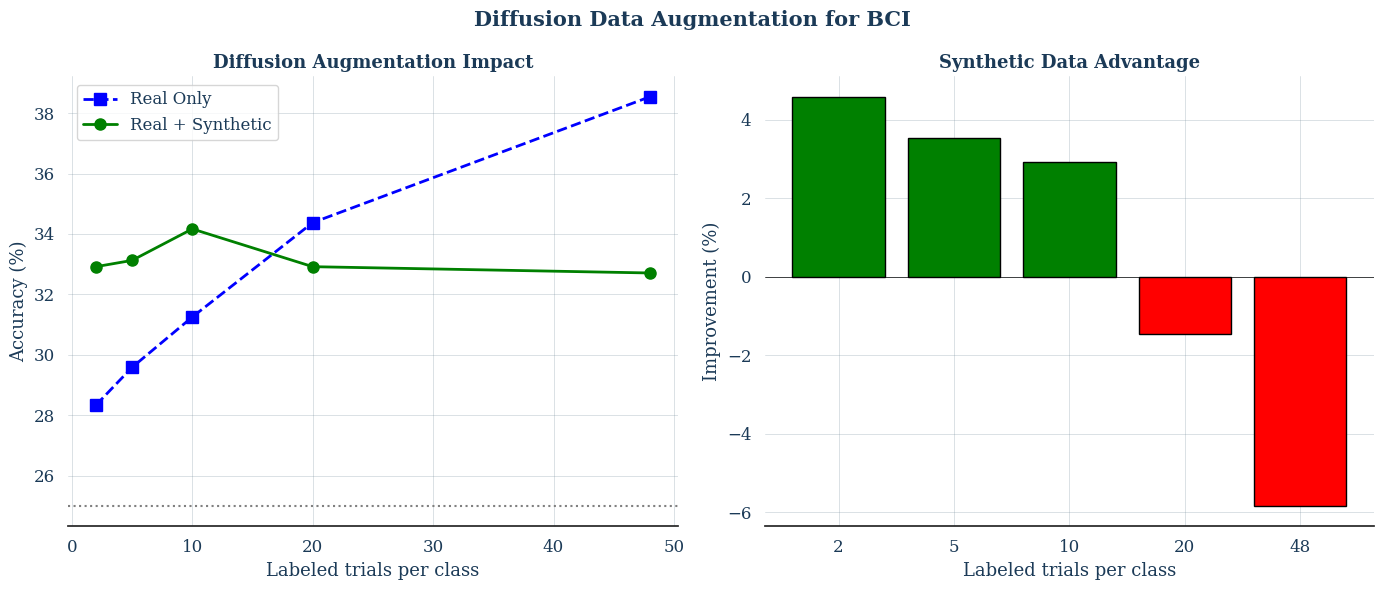


LEVEL 5B COMPLETE: DIFFUSION MODEL FOR EEG

Diffusion Model: 1,750,870 parameters
Real trials: 432
Synthetic trials: 800
Combined: 1232

Ready to feed into Auto Research Loop (Level 6)


In [6]:
# ===== FIXED TRAINING — DEVICE-SAFE =====
print("="*60)
print("TRAINING EEG DIFFUSION MODEL")
print("="*60)

n_diffusion_steps = 500

# Rebuild scheduler with device-safe methods
class DiffusionSchedulerFixed:
    def __init__(self, n_steps=500, device='cuda'):
        self.n_steps = n_steps
        self.device = device
        
        steps = np.arange(n_steps + 1) / n_steps
        alpha_bar = np.cos((steps + 0.008) / 1.008 * np.pi / 2) ** 2
        alpha_bar = alpha_bar / alpha_bar[0]
        betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
        betas = np.clip(betas, 0.0001, 0.02)
        
        self.betas = torch.FloatTensor(betas).to(device)
        self.alphas = (1 - self.betas).to(device)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars).to(device)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - self.alpha_bars).to(device)
    
    def add_noise(self, x, t):
        sqrt_ab = self.sqrt_alpha_bars[t].view(-1, 1, 1)
        sqrt_one_minus_ab = self.sqrt_one_minus_alpha_bars[t].view(-1, 1, 1)
        noise = torch.randn_like(x)
        noisy = sqrt_ab * x + sqrt_one_minus_ab * noise
        return noisy, noise
    
    @torch.no_grad()
    def sample_step(self, model, x_t, t, class_label):
        t_tensor = torch.full((x_t.shape[0],), t, dtype=torch.long, device=self.device)
        predicted_noise = model(x_t, t_tensor, class_label)
        
        beta = self.betas[t]
        alpha = self.alphas[t]
        alpha_bar = self.alpha_bars[t]
        
        x_0_pred = (x_t - torch.sqrt(1 - alpha_bar) * predicted_noise) / torch.sqrt(alpha_bar)
        x_0_pred = torch.clamp(x_0_pred, -3, 3)
        
        if t > 0:
            noise = torch.randn_like(x_t)
            sigma = torch.sqrt(beta)
            x_prev = torch.sqrt(alpha) * x_t + beta / torch.sqrt(1 - alpha_bar) * (x_0_pred - x_t)
            x_prev = x_prev + sigma * noise * 0.5
        else:
            x_prev = x_0_pred
        
        return x_prev

scheduler = DiffusionSchedulerFixed(n_steps=n_diffusion_steps, device=device)

# Rebuild diffusion model
diffusion = EEGDiffusionModel(
    n_channels=n_channels,
    n_samples=n_samples,
    n_classes=n_classes,
    hidden_dim=64,
    time_dim=64,
    n_blocks=6
).to(device)

diff_params = sum(p.numel() for p in diffusion.parameters())
print(f"Diffusion Model: {diff_params:,} parameters")
print(f"Training on {len(X_all)} real trials...\n")

optimizer = optim.AdamW(diffusion.parameters(), lr=0.0003, weight_decay=0.01)
scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

X_tensor = torch.FloatTensor(X_all).to(device)
y_tensor = torch.LongTensor(y_all).to(device)
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

n_epochs = 80
losses = []

for epoch in range(n_epochs):
    diffusion.train()
    epoch_loss = 0
    n_batches = 0
    
    for batch_x, batch_y in train_loader:
        t = torch.randint(0, n_diffusion_steps, (batch_x.shape[0],), device=device)
        noisy_x, noise = scheduler.add_noise(batch_x, t)
        noise_pred = diffusion(noisy_x, t, batch_y)
        loss = F.mse_loss(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    scheduler_lr.step()
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.6f}")

print(f"\nTraining complete! Final loss: {losses[-1]:.6f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, linewidth=2, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Diffusion Model Training — Learning to Denoise EEG', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== GENERATE SYNTHETIC EEG =====
print("\n" + "="*60)
print("GENERATING SYNTHETIC EEG TRIALS")
print("="*60)

@torch.no_grad()
def generate_synthetic_eeg(model, sched, n_gen, class_label, n_ch=22, n_tp=1001):
    model.eval()
    x = torch.randn(n_gen, n_ch, n_tp).to(device)
    labels = torch.full((n_gen,), class_label, dtype=torch.long).to(device)
    
    step_indices = list(range(0, sched.n_steps, 5))[::-1]
    for t in step_indices:
        x = sched.sample_step(model, x, t, labels)
    
    return x.cpu().numpy()

n_synthetic_per_class = 200
synthetic_X = []
synthetic_y = []

print(f"Generating {n_synthetic_per_class} synthetic trials per class...\n")

for c in range(n_classes):
    print(f"  Generating {class_names[c]}...", end=" ")
    syn = generate_synthetic_eeg(diffusion, scheduler, n_synthetic_per_class, c, n_channels, n_samples)
    synthetic_X.append(syn)
    synthetic_y.append(np.full(n_synthetic_per_class, c))
    print(f"Done!")

X_synthetic = np.concatenate(synthetic_X).astype(np.float32)
y_synthetic = np.concatenate(synthetic_y)

print(f"\nSynthetic: {X_synthetic.shape[0]} trials")
print(f"Real: {X_all.shape[0]} trials")
print(f"Combined: {X_all.shape[0] + X_synthetic.shape[0]} trials")

# ===== VISUALIZE REAL vs SYNTHETIC =====
print("\n" + "="*60)
print("COMPARING REAL vs SYNTHETIC EEG")
print("="*60)

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for c in range(n_classes):
    real_idx = np.where(y_all == c)[0][0]
    syn_idx = np.where(y_synthetic == c)[0][0]
    t_plot = np.arange(min(int(2*sfreq), n_samples)) / sfreq
    n_plot = len(t_plot)
    
    axes[c, 0].plot(t_plot, X_all[real_idx, 7, :n_plot], linewidth=0.8, color='blue')
    axes[c, 0].set_ylabel(f'{class_names[c]}')
    axes[c, 0].grid(True, alpha=0.3)
    
    axes[c, 1].plot(t_plot, X_synthetic[syn_idx, 7, :n_plot], linewidth=0.8, color='red')
    axes[c, 1].grid(True, alpha=0.3)

axes[0, 0].set_title('REAL EEG (C3)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('SYNTHETIC EEG (C3)', fontsize=13, fontweight='bold')
axes[3, 0].set_xlabel('Time (s)')
axes[3, 1].set_xlabel('Time (s)')
fig.suptitle('Real vs Diffusion-Generated EEG', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# PSD comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for c in range(n_classes):
    ax = axes[c//2, c%2]
    
    real_psds = []
    for trial in X_all[y_all == c][:20]:
        freqs, psd = sig.welch(trial[7], fs=sfreq, nperseg=int(sfreq))
        real_psds.append(psd)
    
    syn_psds = []
    for trial in X_synthetic[y_synthetic == c][:20]:
        freqs, psd = sig.welch(trial[7], fs=sfreq, nperseg=int(sfreq))
        syn_psds.append(psd)
    
    ax.semilogy(freqs, np.mean(real_psds, axis=0), linewidth=2, color='blue', label='Real')
    ax.semilogy(freqs, np.mean(syn_psds, axis=0), linewidth=2, color='red', alpha=0.7, label='Synthetic')
    ax.axvspan(8, 12, alpha=0.1, color='orange')
    ax.axvspan(13, 30, alpha=0.1, color='green')
    ax.set_xlim([0, 50])
    ax.set_title(class_names[c], fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('PSD — Real vs Synthetic', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== KEY EXPERIMENT: DOES SYNTHETIC DATA HELP? =====
print("\n" + "="*60)
print("KEY EXPERIMENT: Does synthetic data improve decoding?")
print("="*60)

test_mask = subjects_all == 1
train_mask = subjects_all != 1

X_train_real = X_all[train_mask]
y_train_real = y_all[train_mask]
X_test = X_all[test_mask]
y_test = y_all[test_mask]

b_filt, a_filt = sig.butter(4, [8/(sfreq/2), 30/(sfreq/2)], btype='band')

def extract_features(X_data):
    features = []
    for trial in X_data:
        filtered = sig.filtfilt(b_filt, a_filt, trial, axis=1)
        features.append(np.log(np.var(filtered, axis=1) + 1e-10))
    return np.array(features)

feat_test = extract_features(X_test)

n_shots_list = [2, 5, 10, 20, 48]
real_results = {n: [] for n in n_shots_list}
aug_results = {n: [] for n in n_shots_list}

print("\nComparing Real Only vs Real + Synthetic...\n")

for n_shots in n_shots_list:
    for repeat in range(10):
        rng = np.random.RandomState(repeat)
        
        train_indices = []
        for c in range(n_classes):
            class_idx = np.where(y_train_real == c)[0]
            selected = rng.choice(class_idx, min(n_shots, len(class_idx)), replace=False)
            train_indices.extend(selected)
        train_indices = np.array(train_indices)
        
        # Real only
        try:
            feat_real = extract_features(X_train_real[train_indices])
            lda_r = LinearDiscriminantAnalysis()
            lda_r.fit(feat_real, y_train_real[train_indices])
            acc_r = accuracy_score(y_test, lda_r.predict(feat_test)) * 100
        except:
            acc_r = 25.0
        real_results[n_shots].append(acc_r)
        
        # Real + synthetic
        try:
            syn_indices = []
            for c in range(n_classes):
                syn_idx = np.where(y_synthetic == c)[0]
                syn_indices.extend(rng.choice(syn_idx, 50, replace=False))
            syn_indices = np.array(syn_indices)
            
            X_comb = np.concatenate([X_train_real[train_indices], X_synthetic[syn_indices]])
            y_comb = np.concatenate([y_train_real[train_indices], y_synthetic[syn_indices]])
            
            feat_comb = extract_features(X_comb)
            lda_a = LinearDiscriminantAnalysis()
            lda_a.fit(feat_comb, y_comb)
            acc_a = accuracy_score(y_test, lda_a.predict(feat_test)) * 100
        except:
            acc_a = 25.0
        aug_results[n_shots].append(acc_a)
    
    r_mean = np.mean(real_results[n_shots])
    a_mean = np.mean(aug_results[n_shots])
    diff = a_mean - r_mean
    marker = "✓" if diff > 0 else "✗"
    print(f"  {n_shots:2d}-shot — Real: {r_mean:.1f}% | Real+Syn: {a_mean:.1f}% | Δ: {diff:+.1f}% {marker}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

r_means = [np.mean(real_results[n]) for n in n_shots_list]
a_means = [np.mean(aug_results[n]) for n in n_shots_list]

axes[0].plot(n_shots_list, r_means, 's--', linewidth=2, markersize=8, label='Real Only', color='blue')
axes[0].plot(n_shots_list, a_means, 'o-', linewidth=2, markersize=8, label='Real + Synthetic', color='green')
axes[0].axhline(y=25, color='gray', linestyle=':')
axes[0].set_xlabel('Labeled trials per class')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Diffusion Augmentation Impact', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

improvements = [a - r for a, r in zip(a_means, r_means)]
colors_bar = ['green' if i > 0 else 'red' for i in improvements]
axes[1].bar([str(n) for n in n_shots_list], improvements, color=colors_bar, edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Labeled trials per class')
axes[1].set_ylabel('Improvement (%)')
axes[1].set_title('Synthetic Data Advantage', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('Diffusion Data Augmentation for BCI', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("LEVEL 5B COMPLETE: DIFFUSION MODEL FOR EEG")
print("="*60)
print(f"\nDiffusion Model: {diff_params:,} parameters")
print(f"Real trials: {X_all.shape[0]}")
print(f"Synthetic trials: {X_synthetic.shape[0]}")
print(f"Combined: {X_all.shape[0] + X_synthetic.shape[0]}")
print("\nReady to feed into Auto Research Loop (Level 6)")